In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
import seaborn as sns

In [ ]:
df = pd.read_csv("C:/Users/preet/Desktop/ML/Datasets/Student_Performance_sp.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].replace({"No" : 0, "Yes" : 1})
df.head()

C:\Users\preet\AppData\Local\Temp\ipykernel_17828\495256024.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Extracurricular Activities"] = df["Extracurricular Activities"].replace({"No" : 0, "Yes" : 1})


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


# Relation between features and target variable

<Axes: xlabel='Hours Studied', ylabel='Performance Index'>

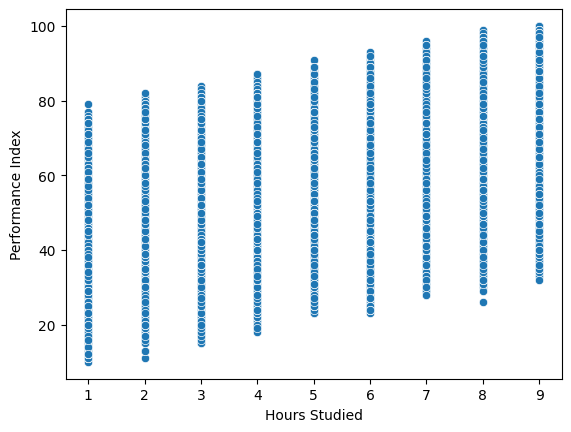

In [4]:
sns.scatterplot(df, x = "Hours Studied", y = "Performance Index")

__Conclusion :__
The relation between hour studied and performance index is linear

<Axes: xlabel='Previous Scores', ylabel='Performance Index'>

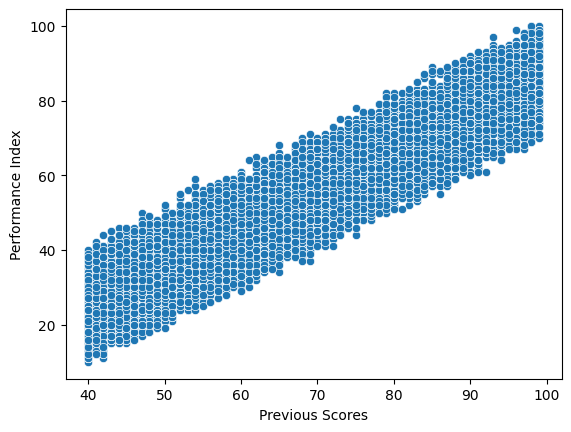

In [5]:
sns.scatterplot(df, x = "Previous Scores", y = "Performance Index")

__Conclusion :__ The relation between previous score and performance index is linear.

<Axes: xlabel='Extracurricular Activities', ylabel='Performance Index'>

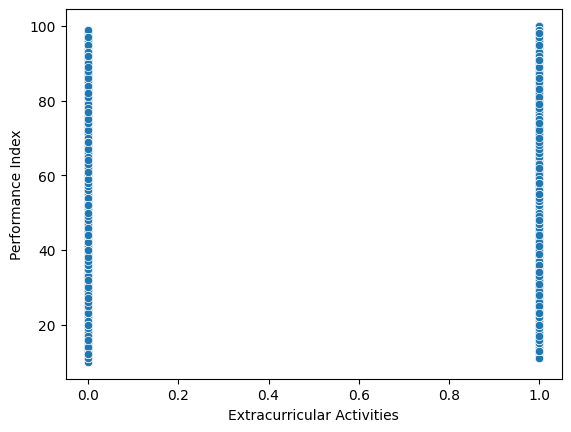

In [6]:
sns.scatterplot(df, x = "Extracurricular Activities", y = "Performance Index")

<Axes: xlabel='Sleep Hours', ylabel='Performance Index'>

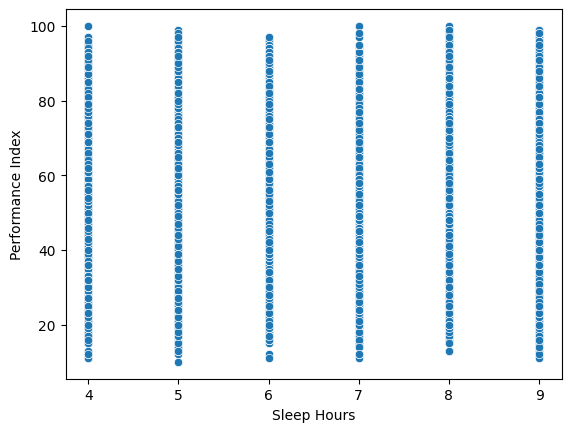

In [7]:
sns.scatterplot(df, x = "Sleep Hours", y = "Performance Index")

__Conclusion :__ The relation between Sleep Hours and performance index is linear.

<Axes: xlabel='Sample Question Papers Practiced', ylabel='Performance Index'>

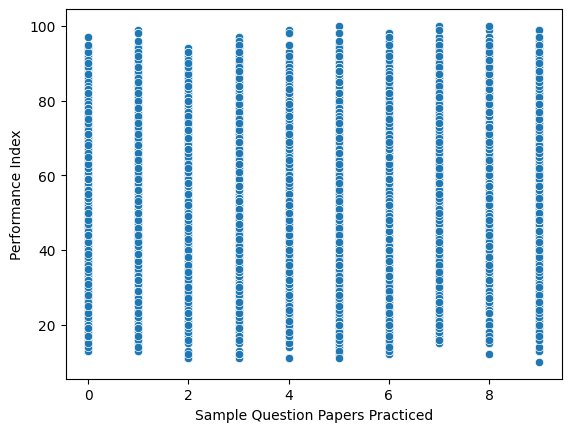

In [8]:
sns.scatterplot(df, x = "Sample Question Papers Practiced", y = "Performance Index")

<Axes: >

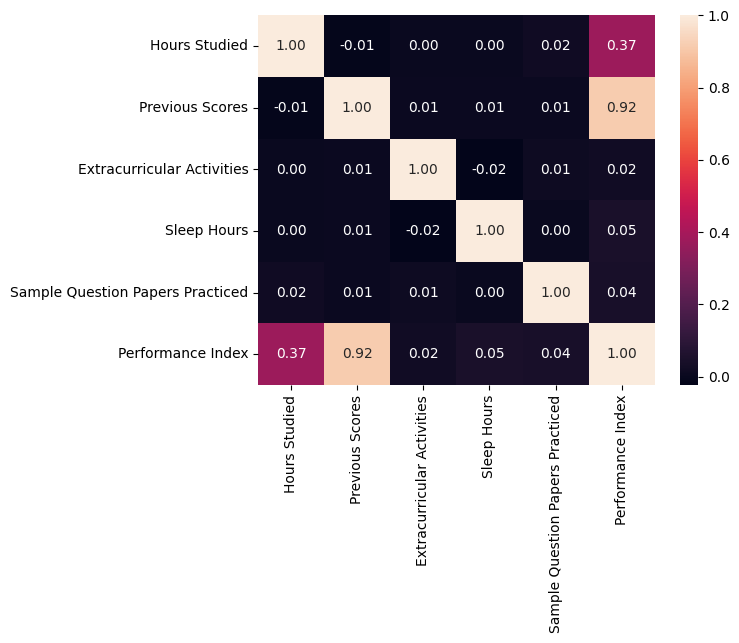

In [31]:
sns.heatmap(df.corr(), annot=True, fmt = ".2f")

In [30]:
df.corr()["Performance Index"]

Hours Studied                       0.373730
Previous Scores                     0.915189
Extracurricular Activities          0.024525
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Performance Index                   1.000000
Name: Performance Index, dtype: float64

In [10]:
# X = df[["Hours Studied","Previous Scores","Sleep Hours","Sample Question Papers Practiced"]]
X = df.drop("Performance Index", axis = 1)
y = df["Performance Index"]

In [11]:
xtrain, xtest, ytrain, ytest = train_test_split(X,y, train_size=0.8, random_state=42)

In [12]:
model = LinearRegression()

In [13]:
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
ypred = model.predict(xtrain)

In [15]:
ytrain - ypred

9254    1.529357
1561   -0.696651
1670    1.118681
6087    0.382041
6669   -0.988844
          ...   
5734    3.631411
5191   -0.511155
5390   -1.055422
860    -1.021456
7270    1.422884
Name: Performance Index, Length: 8000, dtype: float64

In [16]:
mse = mean_squared_error(ytrain, ypred)
mse

4.169735849525007

In [17]:
mae = mean_absolute_error(ytrain,ypred)
mae

1.619305483033428

In [18]:
rmse = root_mean_squared_error(ytrain,ypred)
rmse

2.0419931071198567

In [19]:
print(f"MAE : {mae}")
print(f"RMSE : {rmse}")

MAE : 1.619305483033428
RMSE : 2.0419931071198567


In [20]:
r2 = r2_score(ytrain,ypred)
r2

0.9886898790682355

Here r2_score is 98% so the model performance is good.

<Axes: xlabel='Hours Studied', ylabel='Performance Index'>

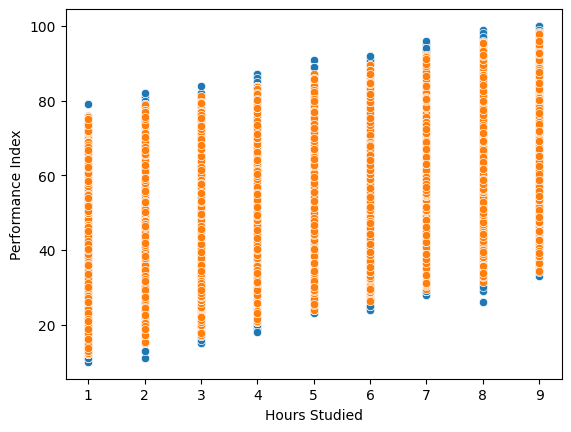

In [21]:
sns.scatterplot(x = xtrain["Hours Studied"], y = ytrain)
sns.scatterplot(x=xtrain["Hours Studied"], y = ypred)

<Axes: xlabel='Previous Scores', ylabel='Performance Index'>

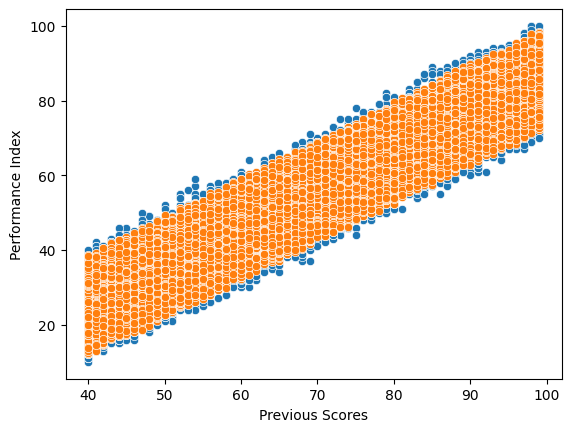

In [22]:
sns.scatterplot(x = xtrain["Previous Scores"], y = ytrain)
sns.scatterplot(x=xtrain["Previous Scores"], y = ypred)

<Axes: xlabel='Extracurricular Activities', ylabel='Performance Index'>

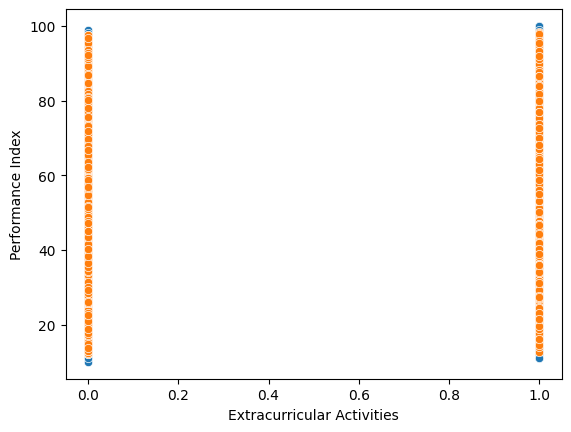

In [23]:
sns.scatterplot(x = xtrain["Extracurricular Activities"], y = ytrain)
sns.scatterplot(x=xtrain["Extracurricular Activities"], y = ypred)

<Axes: xlabel='Sleep Hours', ylabel='Performance Index'>

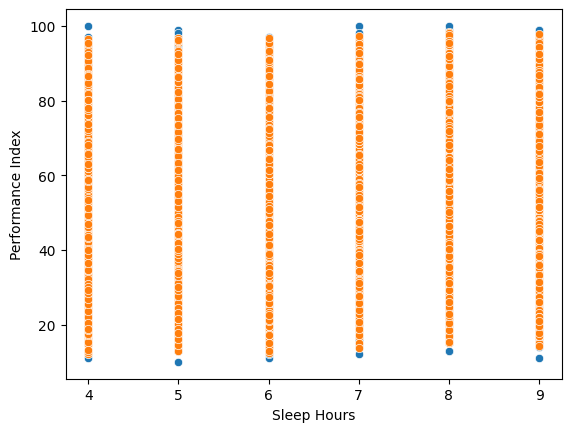

In [24]:
sns.scatterplot(x = xtrain["Sleep Hours"], y = ytrain)
sns.scatterplot(x=xtrain["Sleep Hours"], y = ypred)

<Axes: xlabel='Sample Question Papers Practiced', ylabel='Performance Index'>

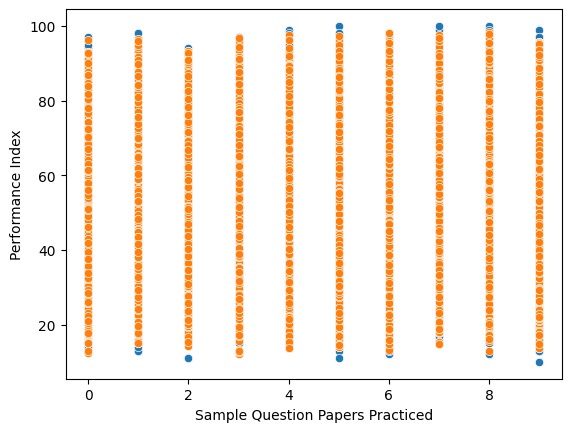

In [25]:
sns.scatterplot(x = xtrain["Sample Question Papers Practiced"], y = ytrain)
sns.scatterplot(x=xtrain["Sample Question Papers Practiced"], y = ypred)

In [27]:
model.score(xtrain,ytrain)   # Same as R2_score but didnot need ypred

0.9886898790682355

# ---------------------------------------------------------------

# Without Previous Score Column

In [33]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [35]:
X = df.drop(["Previous Scores","Performance Index"], axis = 1)
y = df["Performance Index"]

In [42]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y,train_size= 0.8, random_state=42)

In [43]:
model = LinearRegression()

In [44]:
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [45]:
model.score(xtrain,ytrain)

0.14513019870844934